# 📈 Consumer Price Index (CPI) Analysis
**Dataset:** IMF CPI Dataset — Global Monthly Inflation Data (2025–2026)  
**Goal:** Explore inflation patterns across countries & COICOP categories, then predict CPI trends using Machine Learning.

## 1. Import Libraries

In [35]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## 2. Load & Inspect the Dataset

In [36]:
df = pd.read_csv('dataset.csv')
df.columns = df.columns.str.strip()

print("Shape:", df.shape)
print("\nColumns:", list(df.columns))

df.head()

Shape: (15395, 22)

Columns: ['DATASET', 'SERIES_CODE', 'OBS_MEASURE', 'COUNTRY', 'INDEX_TYPE', 'COICOP_1999', 'TYPE_OF_TRANSFORMATION', 'FREQUENCY', 'SCALE', '2025-M04', '2025-M05', '2025-M06', '2025-M07', '2025-M08', '2025-M09', '2025-M10', '2025-M11', '2025-M12', '2026', '2026-M01', '2026-M02', '2026-M03']


,DATASET,SERIES_CODE,OBS_MEASURE,COUNTRY,INDEX_TYPE,COICOP_1999,TYPE_OF_TRANSFORMATION,FREQUENCY,SCALE,2025-M04,...,2025-M07,2025-M08,2025-M09,2025-M10,2025-M11,2025-M12,2026,2026-M01,2026-M02,2026-M03
0,IMF.STA:CPI(5.0.0),CAN.CPI.CP03.WGT.M,OBS_VALUE,Canada,Consumer price index (CPI),Clothing and footwear,Weight,Monthly,Units,41.911560,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,IMF.STA:CPI(5.0.0),CAN.CPI.CP08.WGT.M,OBS_VALUE,Canada,Consumer price index (CPI),Communication,Weight,Monthly,Units,27.213990,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,IMF.STA:CPI(5.0.0),CAN.CPI.CP10.YOY_PCH_PA_PT.M,OBS_VALUE,Canada,Consumer price index (CPI),Education,"Period average, Year-over-year (YOY) percent c...",Monthly,Units,1.597981,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,IMF.STA:CPI(5.0.0),CAN.CPI.CP10.WGT_PT.M,OBS_VALUE,Canada,Consumer price index (CPI),Education,"Weight, Percent",Monthly,Units,1.635270,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,IMF.STA:CPI(5.0.0),CAN.CPI.CP10.WGT.M,OBS_VALUE,Canada,Consumer price index (CPI),Education,Weight,Monthly,Units,16.352700,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15395 entries, 0 to 15394
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   DATASET                 15395 non-null  object 
 1   SERIES_CODE             15395 non-null  object 
 2   OBS_MEASURE             15395 non-null  object 
 3   COUNTRY                 15395 non-null  object 
 4   INDEX_TYPE              15395 non-null  object 
 5   COICOP_1999             15395 non-null  object 
 6   TYPE_OF_TRANSFORMATION  15395 non-null  object 
 7   FREQUENCY               15395 non-null  object 
 8   SCALE                   15395 non-null  object 
 9   2025-M04                8384 non-null   float64
 10  2025-M05                8324 non-null   float64
 11  2025-M06                8204 non-null   float64
 12  2025-M07                8006 non-null   float64
 13  2025-M08                7964 non-null   float64
 14  2025-M09                7736 non-null 

In [38]:
print("Unique Countries:", df['COUNTRY'].nunique())

cols = ['INDEX_TYPE', 'COICOP_1999', 'TYPE_OF_TRANSFORMATION']

for col in cols:
    print(f"\n{col}:\n", df[col].value_counts())

Unique Countries: 173

INDEX_TYPE:
 INDEX_TYPE
Consumer price index (CPI)                    12835
Harmonised index of consumer prices (HICP)     2560
Name: count, dtype: int64

COICOP_1999:
 COICOP_1999
All Items                                                             2165
Food and non-alcoholic beverages                                      1111
Clothing and footwear                                                 1109
Health                                                                1109
Recreation and culture                                                1109
Transport                                                             1109
Housing, water, electricity, gas and other fuels                      1109
Furnishings, household equipment and routine household maintenance    1103
Miscellaneous goods and services                                      1099
Communication                                                         1097
Restaurants and hotels                        

## 3. Data Cleaning & Preprocessing

In [39]:
# Monthly columns
month_cols = ['2025-M04','2025-M05','2025-M06','2025-M07','2025-M08',
              '2025-M09','2025-M10','2025-M11','2025-M12',
              '2026-M01','2026-M02','2026-M03']

# Filter CPI YOY data
yoy_df = df[
    (df['INDEX_TYPE'] == 'Consumer price index (CPI)') &
    (df['TYPE_OF_TRANSFORMATION'].str.contains('Year-over-year', na=False))
].copy()

print("YOY % Change rows:", len(yoy_df))

# Convert to numeric (important)
yoy_df[month_cols] = yoy_df[month_cols].apply(pd.to_numeric, errors='coerce')

# Create target
yoy_df['avg_yoy_inflation'] = yoy_df[month_cols].mean(axis=1)

# Remove empty rows
yoy_df = yoy_df.dropna(subset=['avg_yoy_inflation'])

print("After removing empty rows:", len(yoy_df))

yoy_df[['COUNTRY','COICOP_1999','avg_yoy_inflation'] + month_cols[:4]].head()

YOY % Change rows: 2865
After removing empty rows: 1528


,COUNTRY,COICOP_1999,avg_yoy_inflation,2025-M04,2025-M05,2025-M06,2025-M07
2,Canada,Education,1.597981,1.597981,NaN,NaN,NaN
6,Canada,Food and non-alcoholic beverages,3.848238,3.848238,NaN,NaN,NaN
10,Canada,Communication,-1.709402,-1.709402,NaN,NaN,NaN
14,Canada,Clothing and footwear,-0.970874,-0.970874,NaN,NaN,NaN
17,Canada,Health,2.631579,2.631579,NaN,NaN,NaN


In [40]:
##4. Feature Scaling (MinMax Scaling)

In [41]:
scaler = MinMaxScaler()

# Apply scaling to numeric columns
num_cols = yoy_df.select_dtypes(include='number').columns
yoy_scaled = yoy_df.copy()
yoy_scaled[num_cols] = scaler.fit_transform(yoy_df[num_cols].fillna(0))

# Show result
print("Before Scaling:")
print(yoy_df[num_cols].head())

print("\nAfter MinMax Scaling:")
print(yoy_scaled[num_cols].head())

Before Scaling:
    2025-M04  2025-M05  2025-M06  2025-M07  2025-M08  2025-M09  2025-M10  \
2   1.597981       NaN       NaN       NaN       NaN       NaN       NaN   
6   3.848238       NaN       NaN       NaN       NaN       NaN       NaN   
10 -1.709402       NaN       NaN       NaN       NaN       NaN       NaN   
14 -0.970874       NaN       NaN       NaN       NaN       NaN       NaN   
17  2.631579       NaN       NaN       NaN       NaN       NaN       NaN   

    2025-M11  2025-M12  2026  2026-M01  2026-M02  2026-M03  avg_yoy_inflation  
2        NaN       NaN   NaN       NaN       NaN       NaN           1.597981  
6        NaN       NaN   NaN       NaN       NaN       NaN           3.848238  
10       NaN       NaN   NaN       NaN       NaN       NaN          -1.709402  
14       NaN       NaN   NaN       NaN       NaN       NaN          -0.970874  
17       NaN       NaN   NaN       NaN       NaN       NaN           2.631579  

After MinMax Scaling:
    2025-M04  2025-M05  

In [42]:
## 4.1 Scaling Visualization

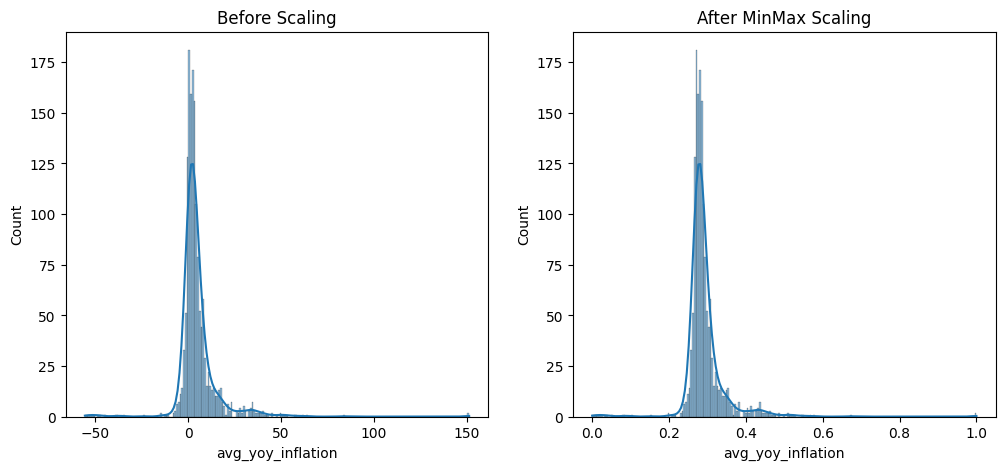

In [43]:
plt.figure(figsize=(12,5))

for i, data in enumerate([yoy_df, yoy_scaled], 1):
    plt.subplot(1, 2, i)
    sns.histplot(data['avg_yoy_inflation'], kde=True)
    plt.title("Before Scaling" if i == 1 else "After MinMax Scaling")

plt.show()

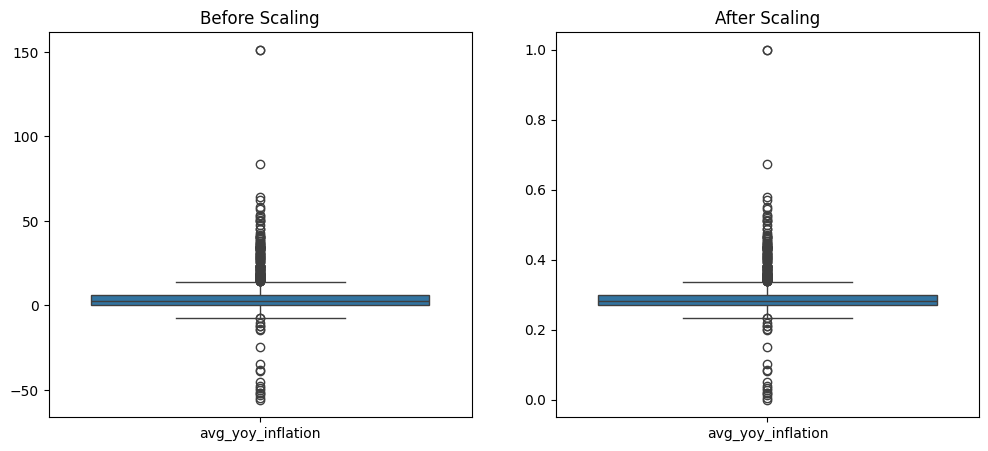

In [44]:
plt.figure(figsize=(12,5))

for i, data in enumerate([yoy_df, yoy_scaled], 1):
    plt.subplot(1, 2, i)
    sns.boxplot(data=data[['avg_yoy_inflation']])
    plt.title("Before Scaling" if i == 1 else "After Scaling")

plt.show()

## 4. Exploratory Data Analysis (EDA)

### 4.1 Distribution of YOY Inflation Rates

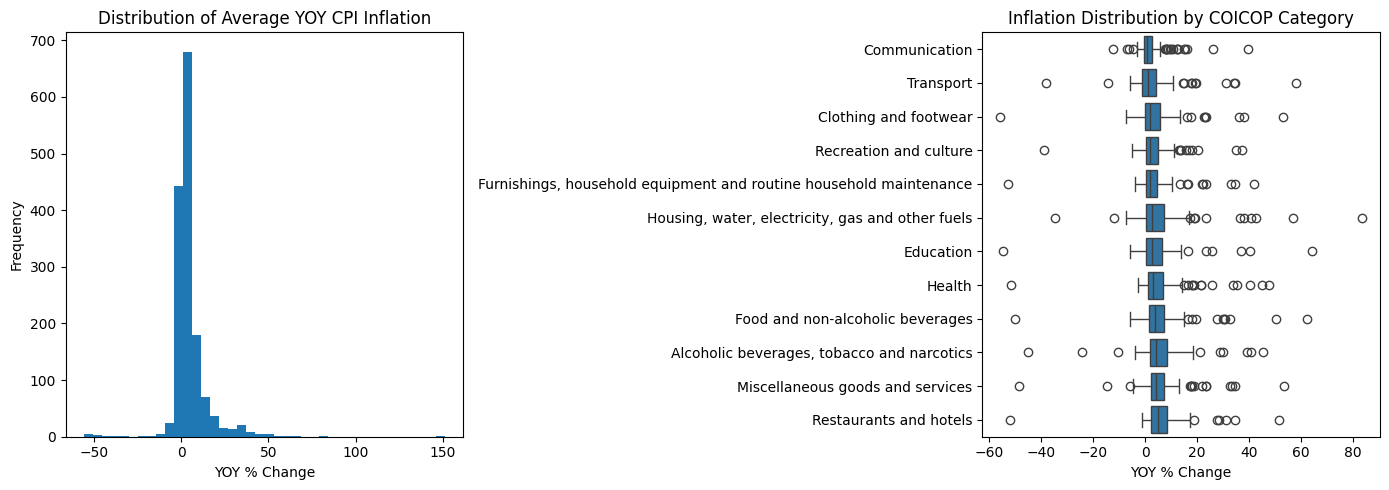

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(yoy_df['avg_yoy_inflation'].dropna(), bins=40)
axes[0].set(title='Distribution of Average YOY CPI Inflation',
            xlabel='YOY % Change', ylabel='Frequency')

# Boxplot by COICOP
cat_data = yoy_df[yoy_df['COICOP_1999'] != 'All Items']
order = cat_data.groupby('COICOP_1999')['avg_yoy_inflation'].median().sort_values().index

sns.boxplot(data=cat_data, y='COICOP_1999', x='avg_yoy_inflation',
            order=order, ax=axes[1])

axes[1].set(title='Inflation Distribution by COICOP Category',
            xlabel='YOY % Change', ylabel='')

plt.tight_layout()
plt.show()

### 4.2 Top 15 Countries by Average Inflation (All Items)

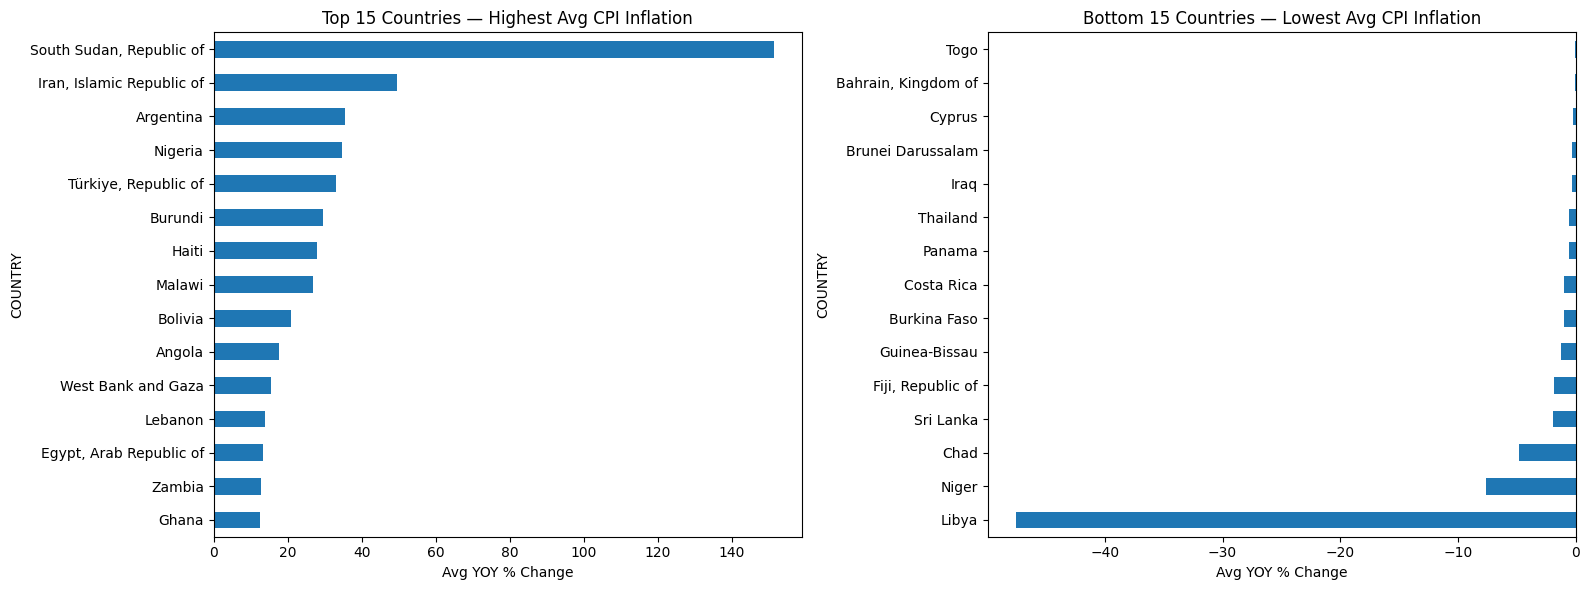

Highest inflation country: South Sudan, Republic of
Lowest inflation country: Libya


In [46]:
# Country-level inflation (All Items)
all_items = yoy_df[yoy_df['COICOP_1999'] == 'All Items']

country_avg = all_items.groupby('COUNTRY')['avg_yoy_inflation'].mean().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for i, data in enumerate([country_avg.head(15), country_avg.tail(15)]):
    data.plot(kind='barh', ax=axes[i])
    axes[i].set(
        title='Top 15 Countries — Highest Avg CPI Inflation' if i == 0 
              else 'Bottom 15 Countries — Lowest Avg CPI Inflation',
        xlabel='Avg YOY % Change'
    )
    axes[i].invert_yaxis()

plt.tight_layout()
plt.show()

print("Highest inflation country:", country_avg.idxmax())
print("Lowest inflation country:", country_avg.idxmin())

### 4.3 Category-wise Inflation — Global Average

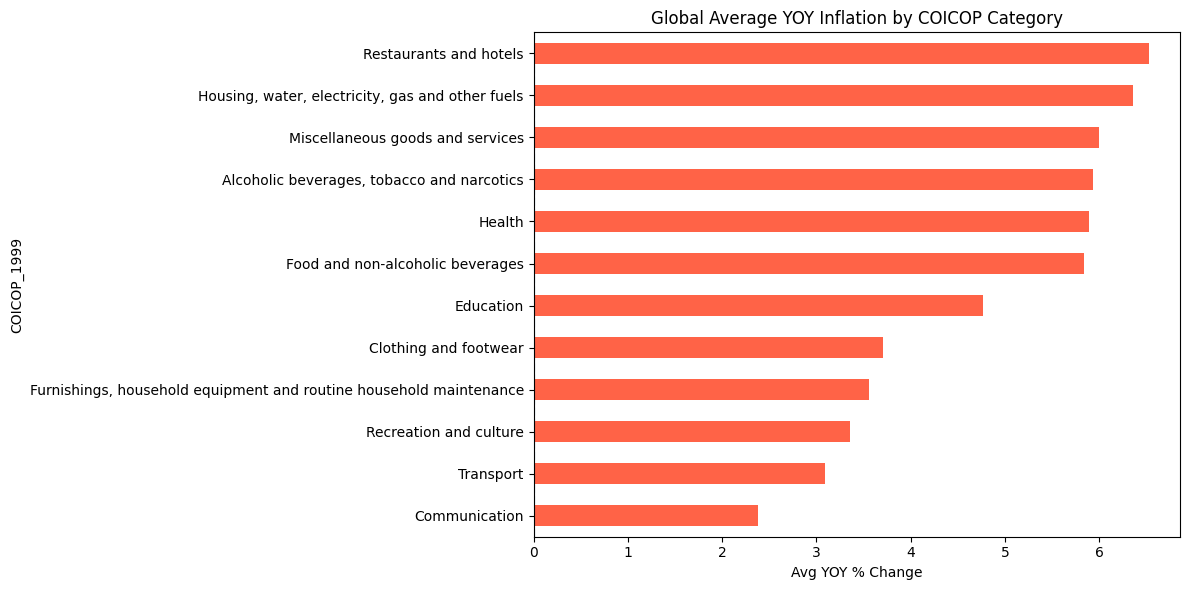

Most inflationary category: Restaurants and hotels
Least inflationary category: Communication


In [47]:
cat_avg = yoy_df[yoy_df['COICOP_1999'] != 'All Items'] \
    .groupby('COICOP_1999')['avg_yoy_inflation'] \
    .mean().sort_values()

plt.figure(figsize=(12, 6))
cat_avg.plot(kind='barh',
             color=['tomato' if v > 0 else 'steelblue' for v in cat_avg])

plt.axvline(0, linestyle='--')
plt.title('Global Average YOY Inflation by COICOP Category')
plt.xlabel('Avg YOY % Change')
plt.tight_layout()
plt.show()

print("Most inflationary category:", cat_avg.idxmax())
print("Least inflationary category:", cat_avg.idxmin())

### 4.4 Monthly Trend — Top 5 High-Inflation Countries

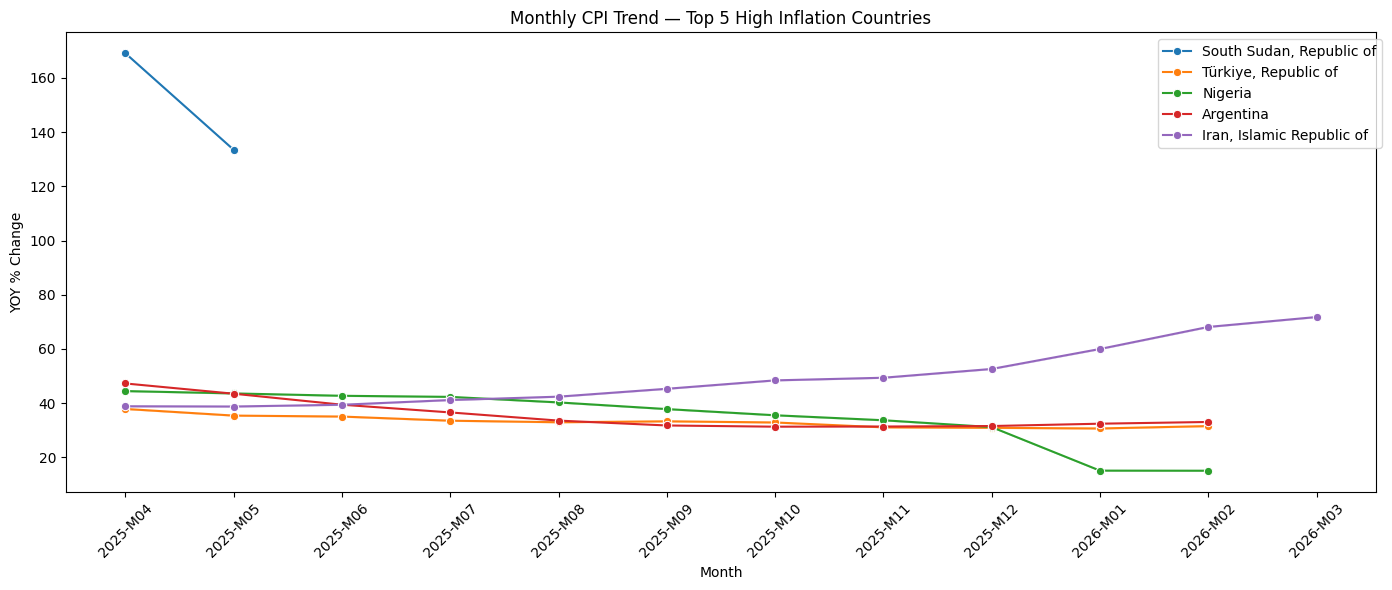

In [48]:
top5 = country_avg.head(5).index

trend = all_items[all_items['COUNTRY'].isin(top5)][['COUNTRY'] + month_cols] \
    .melt(id_vars='COUNTRY', var_name='Month', value_name='YOY_Inflation')

plt.figure(figsize=(14, 6))
sns.lineplot(data=trend, x='Month', y='YOY_Inflation', hue='COUNTRY', marker='o')

plt.title('Monthly CPI Trend — Top 5 High Inflation Countries')
plt.xlabel('Month')
plt.ylabel('YOY % Change')
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.show()

### 4.5 Correlation Heatmap — Monthly CPI Values

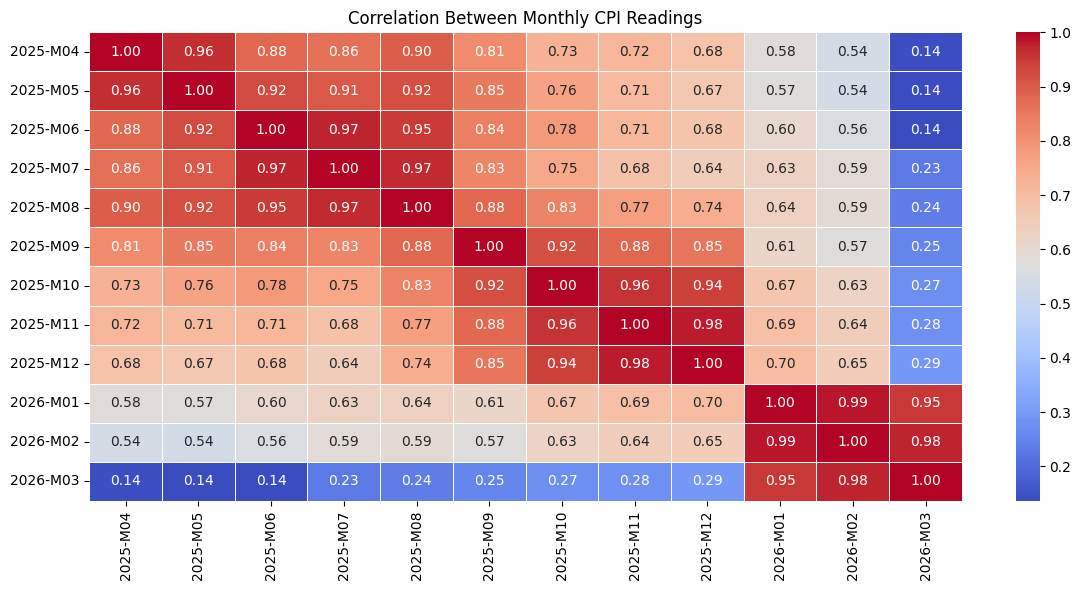

In [49]:
plt.figure(figsize=(12, 6))

sns.heatmap(yoy_df[month_cols].corr(),
            annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)

plt.title('Correlation Between Monthly CPI Readings')
plt.tight_layout()
plt.show()

### 4.6 Pairplot — Selected Months

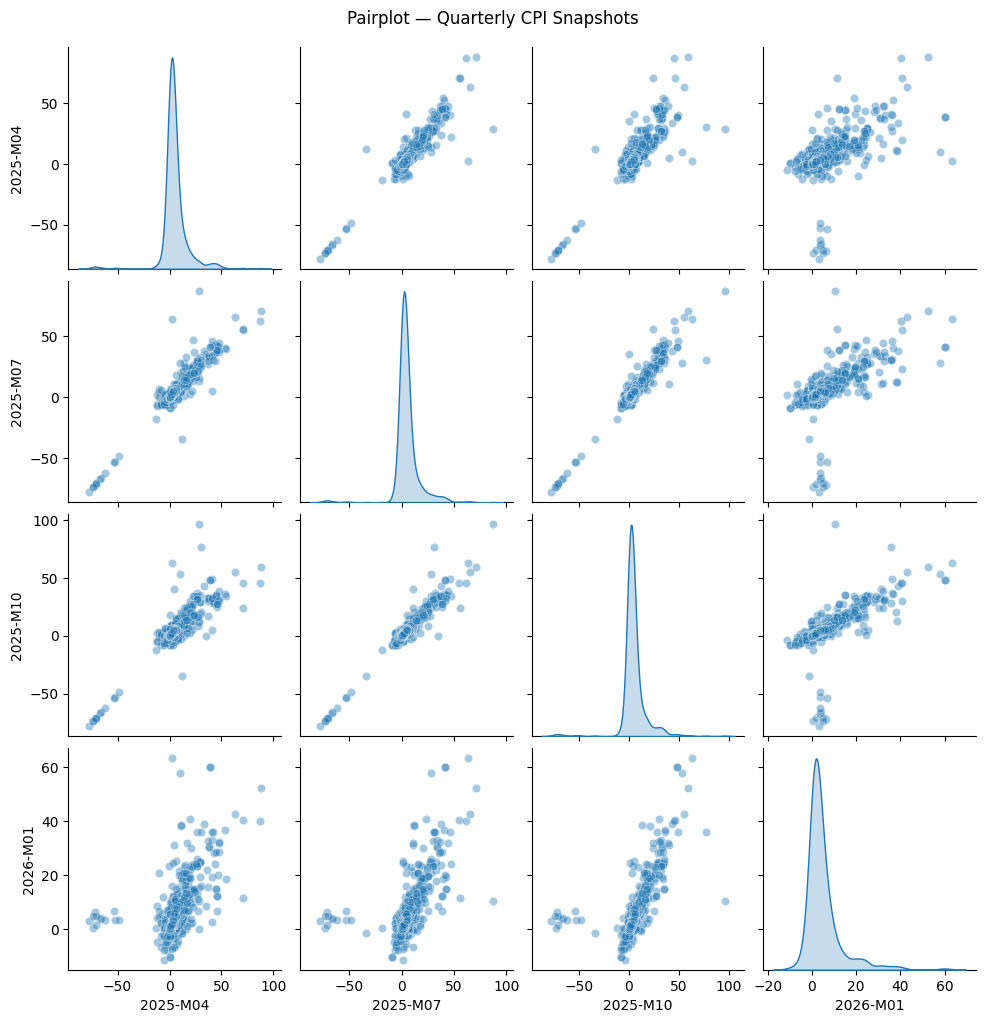

In [50]:
sample_months = ['2025-M04','2025-M07','2025-M10','2026-M01']

sns.pairplot(yoy_df[sample_months].dropna(),
             diag_kind='kde', plot_kws={'alpha':0.4})

plt.suptitle('Pairplot — Quarterly CPI Snapshots', y=1.02)
plt.show()

### 4.7 Outlier Detection — Boxplot of Monthly Readings

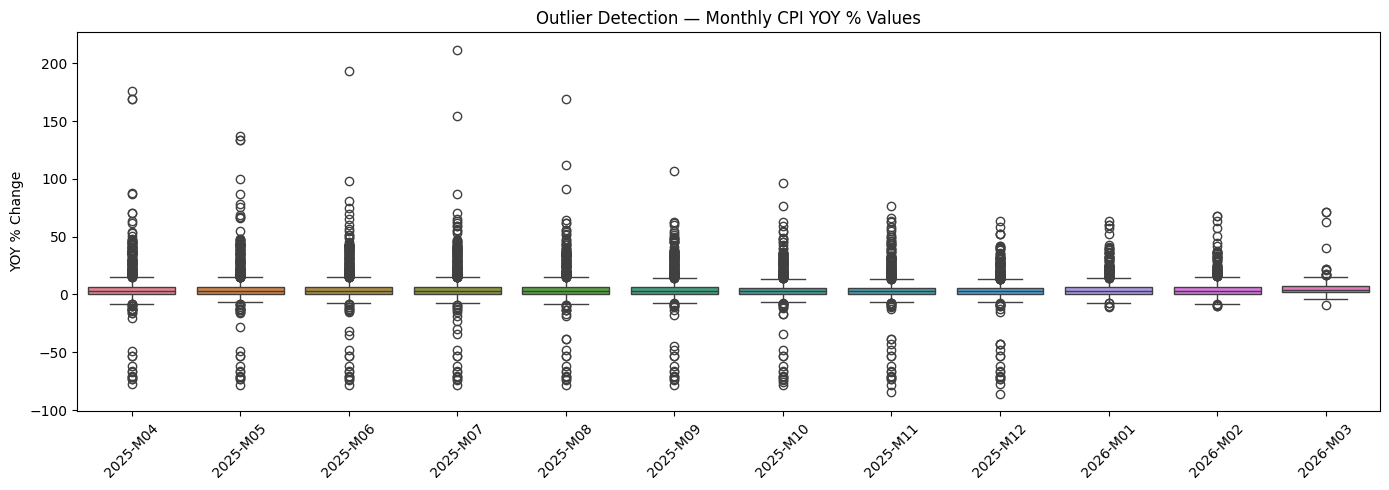

In [51]:
plt.figure(figsize=(14, 5))

sns.boxplot(data=yoy_df[month_cols])
plt.xticks(rotation=45)

plt.title('Outlier Detection — Monthly CPI YOY % Values')
plt.ylabel('YOY % Change')

plt.tight_layout()
plt.show()

## 5. Feature Engineering for ML

In [52]:
# Keep rows with at least 6 valid month values
ml_df = yoy_df.dropna(subset=month_cols, thresh=6).copy()

# Features and target
feature_months = ['2025-M04','2025-M05','2025-M06','2025-M07','2025-M08','2025-M09']
target = 'avg_yoy_inflation'

# Encode categories
le_cat = LabelEncoder()
le_ctry = LabelEncoder()

ml_df['cat_encoded'] = le_cat.fit_transform(ml_df['COICOP_1999'].astype(str))
ml_df['country_encoded'] = le_ctry.fit_transform(ml_df['COUNTRY'].astype(str))

# Create X and y
X = ml_df[feature_months + ['cat_encoded', 'country_encoded']]
y = ml_df[target]

print("Final ML dataset shape:", X.shape)
print("Features:", list(X.columns))

Final ML dataset shape: (1416, 8)
Features: ['2025-M04', '2025-M05', '2025-M06', '2025-M07', '2025-M08', '2025-M09', 'cat_encoded', 'country_encoded']


## 6. Model Training

In [53]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Scaling
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)

print("Model trained!")

Model trained!


## 7. Model Evaluation

In [54]:
def evaluate(name, y_true, y_pred):
    print(f"\n--- {name} ---")
    print("MAE :", round(mean_absolute_error(y_true, y_pred), 4))
    print("RMSE:", round(np.sqrt(mean_squared_error(y_true, y_pred)), 4))
    print("R²  :", round(r2_score(y_true, y_pred), 4))

# Evaluate Linear Regression
lr_pred = evaluate("Linear Regression", y_test, lr.predict(X_test))


--- Linear Regression ---
MAE : 1.1391
RMSE: 2.85
R²  : 0.9328


### 7.1 Actual vs Predicted — Random Forest

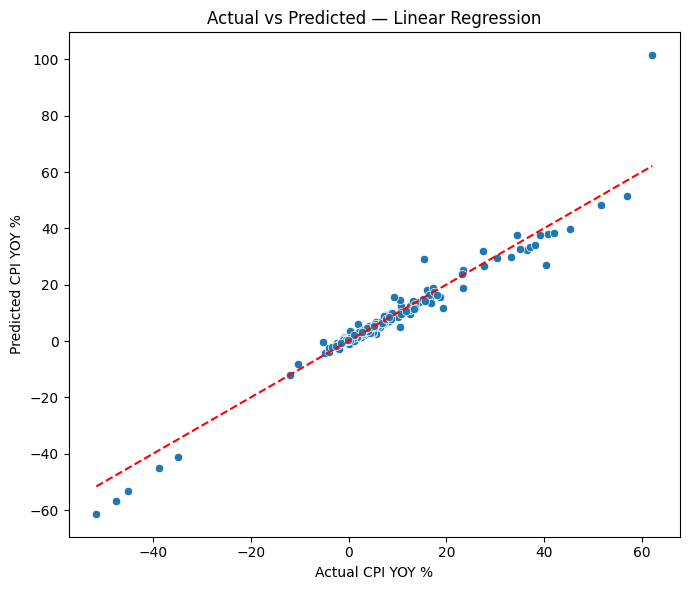

In [64]:
# Ensure proper arrays
y_test_arr = np.array(y_test)
lr_pred_arr = np.array(lr.predict(X_test))

plt.figure(figsize=(7, 6))

sns.scatterplot(x=y_test_arr, y=lr_pred_arr)

# Perfect prediction line
plt.plot([y_test_arr.min(), y_test_arr.max()],
         [y_test_arr.min(), y_test_arr.max()],
         'r--')

plt.xlabel('Actual CPI YOY %')
plt.ylabel('Predicted CPI YOY %')
plt.title('Actual vs Predicted — Linear Regression')

plt.tight_layout()
plt.show()

### 7.2 Residual Distribution

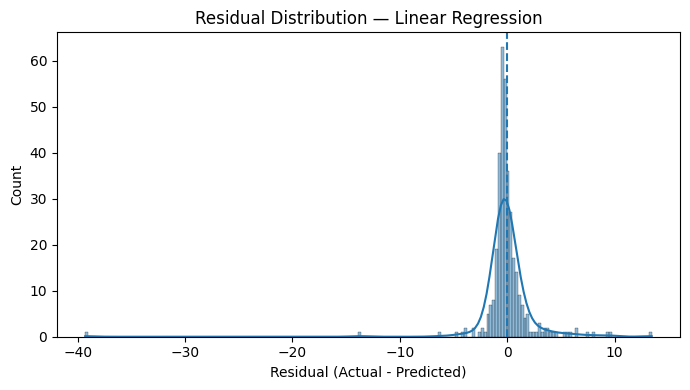

In [63]:
# Make sure prediction exists
lr_pred = lr.predict(X_test)

# Convert to same type (important fix)
y_test_arr = np.array(y_test)
lr_pred_arr = np.array(lr_pred)

# Residuals
residuals = y_test_arr - lr_pred_arr

# Plot
plt.figure(figsize=(7, 4))

sns.histplot(residuals, kde=True)
plt.axvline(0, linestyle='--')

plt.title('Residual Distribution — Linear Regression')
plt.xlabel('Residual (Actual - Predicted)')

plt.tight_layout()
plt.show()

### 7.3 Feature Importance

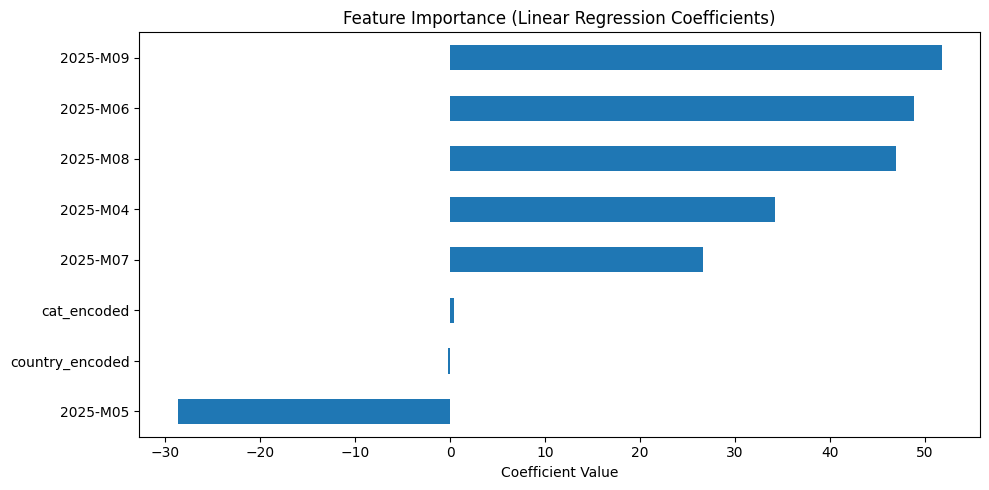

In [57]:
importance = pd.Series(lr.coef_, index=X.columns).sort_values()

plt.figure(figsize=(10, 5))
importance.plot(kind='barh')

plt.title('Feature Importance (Linear Regression Coefficients)')
plt.xlabel('Coefficient Value')

plt.tight_layout()
plt.show()

### 7.4 Model Comparison — R² Score

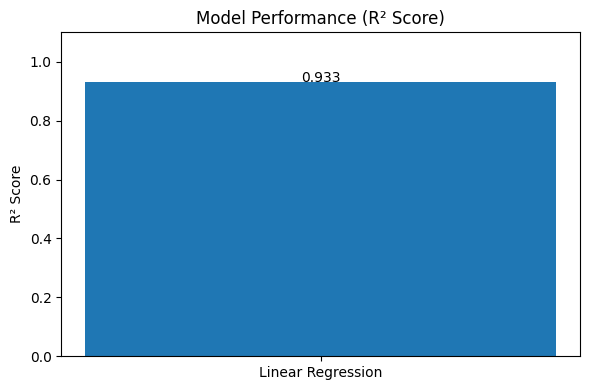

In [61]:
# Calculate predictions FIRST
lr_pred = lr.predict(X_test)

# Calculate R² score
r2 = r2_score(y_test, lr_pred)

# Plot
plt.figure(figsize=(6, 4))
bar = plt.bar(['Linear Regression'], [r2])

# Add value label
plt.text(bar[0].get_x() + bar[0].get_width()/2, r2,
         f'{r2:.3f}', ha='center')

plt.ylim(0, 1.1)
plt.title('Model Performance (R² Score)')
plt.ylabel('R² Score')

plt.tight_layout()
plt.show()

## 8. Key Insights & Conclusions

In [62]:
# Make sure prediction exists
lr_pred = lr.predict(X_test)

print("=" * 55)
print("     CONSUMER PRICE INDEX — KEY FINDINGS")
print("=" * 55)

print("\nTotal countries analyzed :", yoy_df["COUNTRY"].nunique())
print("Total COICOP categories  :", yoy_df["COICOP_1999"].nunique())

print("\n🔺 Highest average inflation:",
      country_avg.idxmax(), f"({country_avg.max():.2f}%)")

print("🔻 Lowest average inflation:",
      country_avg.idxmin(), f"({country_avg.min():.2f}%)")

print("\nMost inflationary category:",
      cat_avg.idxmax(), f"({cat_avg.max():.2f}%)")

print("Least inflationary category:",
      cat_avg.idxmin(), f"({cat_avg.min():.2f}%)")

# FIXED LINE
print(f"\nBest Model R² Score: Linear Regression ({r2_score(y_test, lr_pred):.4f})")

print("\nLinear Regression used for prediction.")
print("=" * 55)

     CONSUMER PRICE INDEX — KEY FINDINGS

Total countries analyzed : 168
Total COICOP categories  : 13

🔺 Highest average inflation: South Sudan, Republic of (151.32%)
🔻 Lowest average inflation: Libya (-47.57%)

Most inflationary category: Restaurants and hotels (6.53%)
Least inflationary category: Communication (2.39%)

Best Model R² Score: Linear Regression (0.9328)

Linear Regression used for prediction.


## 9. Predict CPI for a New Input

In [60]:
def predict_cpi(monthly_values, category_name, country_name):
    try:
        cat = le_cat.transform([category_name])[0]
    except:
        cat = 0

    try:
        ctry = le_ctry.transform([country_name])[0]
    except:
        ctry = 0

    inp = np.array(monthly_values + [cat, ctry]).reshape(1, -1)
    inp = scaler.transform(inp)   # apply same scaling

    pred = lr.predict(inp)[0]

    print(f"Predicted Avg YOY CPI Inflation: {pred:.2f}%")
    return pred

# Example
predict_cpi(
    [4.2, 4.5, 4.8, 5.1, 5.3, 5.0],
    'Food and non-alcoholic beverages',
    'Canada'
)

Predicted Avg YOY CPI Inflation: 5.00%


np.float64(4.996202082333866)